In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!git clone https://github.com/facebookresearch/detectron2.git
!pip install -e detectron2

Cloning into 'detectron2'...
remote: Enumerating objects: 15943, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 15943 (delta 5), reused 4 (delta 4), pack-reused 15931 (from 3)
Receiving objects: 100% (15943/15943), 6.70 MiB | 23.56 MiB/s, done.
Resolving deltas: 100% (11337/11337), done.
Obtaining file:///content/detectron2
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.4/86.4 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.0/55.0 kB 6.6 MB/s eta 0:00:00
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=6e819768be95eac82df4727c2098e19e

In [ ]:
from torchvision.datasets import CocoDetection
from torchvision.models.detection.ssd import SSD300_VGG16_Weights
from torch.utils.data import DataLoader
import os

# Paths
dataset_root = "/content/drive/MyDrive/final_augmentation/coco shear"
ann_root = os.path.join(dataset_root, "annotations")

# Transforms
weights = SSD300_VGG16_Weights.DEFAULT
transform = weights.transforms()

# Datasets
train_dataset = CocoDetection(
    root=os.path.join(dataset_root, "train"),
    annFile=os.path.join(ann_root, "train.json"),
    transform=transform
)

val_dataset = CocoDetection(
    root=os.path.join(dataset_root, "val"),
    annFile=os.path.join(ann_root, "val.json"),
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

loading annotations into memory...
Done (t=0.07s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


In [ ]:
import torchvision
import torch.nn as nn
import torch # Import torch to use torch.device

# Load base SSD model
model = torchvision.models.detection.ssd300_vgg16(weights=weights)

# Modify classifier: 1 class (pothole) + 1 background = 2 total
num_classes = 2

# Correct way to get in_channels for SSDClassificationHead
# The in_channels for the new head should match the out_channels of the feature extractor layers
# feeding into the original classification head.
in_channels_list = [m.in_channels for m in model.head.classification_head.module_list]
print(f"Found in_channels: {in_channels_list}")

# Get num_anchors_per_location from the model's anchor_generator
# It's a method that needs to be called to get the list of anchor counts
num_anchors_per_location = model.anchor_generator.num_anchors_per_location()

# Corrected argument order for SSDClassificationHead
model.head.classification_head = torchvision.models.detection.ssd.SSDClassificationHead(
    in_channels_list, num_anchors_per_location, num_classes
)
print("Successfully replaced classification head.")

# Define device before moving the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to device AFTER all modifications are done
model.to(device)

Found in_channels: [512, 1024, 512, 256, 256, 256]
Successfully replaced classification head.


SSD(
  (backbone): SSDFeatureExtractorVGG(
    (features): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=

In [ ]:
import torch
from tqdm.auto import tqdm # Import tqdm for progress bar

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model.to(device) # This line is moved to cell 8CFqpQ6YwUIH
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Initialize epoch to 0 if not defined
epoch = 0

# Resume training from the last interrupted epoch
# The 'epoch' variable from the previous run stores the index of the interrupted epoch.
# We will use 'current_epoch_idx' for the loop counter to avoid overwriting the 'epoch' variable.
for current_epoch_idx in range(epoch, 100):
    model.train()
    epoch_loss = 0.0
    num_batches = 32
    # Wrap train_loader with tqdm for a progress bar
    for images, targets_tuple in tqdm(train_loader, desc=f"Epoch {current_epoch_idx+1}"):
        images = [img.to(device) for img in images]
        # Correctly process the targets tuple, convert bbox format, filter invalid boxes, and aggregate targets per image
        targets = []
        processed_images = [] # Keep track of images with targets

        for i, targets_list_per_image in enumerate(targets_tuple):
            valid_boxes = []
            valid_labels = []
            valid_area = []
            valid_iscrowd = []

            # Define a small epsilon for floating-point comparison
            epsilon = 1e-5

            # Process and filter bounding boxes
            for target_dict in targets_list_per_image:
                bbox = target_dict['bbox']
                # Assuming original bbox format is [x_min, y_min, width, height]
                x_min, y_min, width, height = bbox

                # Convert to [x_min, y_min, x_max, y_max] format
                x_max = x_min + width
                y_max = y_min + height

                # Filter out invalid bounding boxes (where x_max <= x_min or y_max <= y_min)
                if x_max > x_min + epsilon and y_max > y_min + epsilon:
                    valid_boxes.append([x_min, y_min, x_max, y_max])
                    valid_labels.append(target_dict['category_id'])
                    valid_area.append(target_dict['area'])
                    valid_iscrowd.append(target_dict['iscrowd'])

            # Only process if there are valid targets for this image
            if len(valid_boxes) > 0:
                # Assuming image_id is the same for all targets of an image
                # Find the first valid target to get the image_id
                first_valid_target = next((td for td in targets_list_per_image if (td['bbox'][0] + td['bbox'][2]) > td['bbox'][0] + epsilon and (td['bbox'][1] + td['bbox'][3]) > td['bbox'][1] + epsilon), None)
                if first_valid_target is not None:
                    image_id = first_valid_target['image_id']
                else:
                    # This case should ideally not happen if valid_boxes is not empty, but as a safeguard
                    continue


                # Convert lists to tensors and move to device
                target = {}
                target['boxes'] = torch.as_tensor(valid_boxes, dtype=torch.float32).to(device)
                target['labels'] = torch.as_tensor(valid_labels, dtype=torch.int64).to(device)
                target['image_id'] = torch.tensor([image_id]).to(device) # image_id should be a tensor
                target['area'] = torch.as_tensor(valid_area, dtype=torch.float32).to(device)
                target['iscrowd'] = torch.as_tensor(valid_iscrowd, dtype=torch.int64).to(device)


                targets.append(target)
                processed_images.append(images[i]) # Add the corresponding image


        # Only compute loss if there are images with targets
        if len(processed_images) > 0:
            loss_dict = model(processed_images, targets)
            loss = sum(loss for loss in loss_dict.values())

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1

            # Removed the print statement for individual batch loss
            # print(f"Epoch {current_epoch_idx+1} completed. Loss: {loss.item():.4f}")
        else:
             # This print statement can also be removed for a more concise output
             pass # print(f"Epoch {current_epoch_idx+1} completed. No valid targets found in this batch.")

    if num_batches > 0:
        avg_loss = epoch_loss / num_batches
        print(f"Epoch {current_epoch_idx+1} training finished. Average Loss: {avg_loss:.4f}")
    else:
        print(f"Epoch {current_epoch_idx+1} training finished. No valid batches processed.")

Epoch 1:   0%|          | 0/256 [00:00<?, ?it/s]

Epoch 1 training finished. Average Loss: 2.9265


Epoch 2:   0%|          | 0/256 [00:00<?, ?it/s]

Epoch 2 training finished. Average Loss: 2.0379


Epoch 3:   0%|          | 0/256 [00:00<?, ?it/s]

...

Epoch 98 training finished. Average Loss: 0.0061


Epoch 99:   0%|          | 0/256 [00:00<?, ?it/s]

Epoch 99 training finished. Average Loss: 0.0087


Epoch 100:   0%|          | 0/256 [00:00<?, ?it/s]

Epoch 100 training finished. Average Loss: 0.0119


In [8]:
import torch
from torchvision.ops import box_iou
import numpy as np

def calculate_map_50(predictions, targets, iou_threshold=0.5):
    all_matches = []
    for i in range(len(predictions)):
        pred_boxes = predictions[i]['boxes']
        pred_scores = predictions[i]['scores']
        gt_boxes = targets[i]['boxes']
        gt_labels = targets[i]['labels']

        if pred_boxes.shape[0] == 0 and gt_boxes.shape[0] == 0:
            all_matches.append(None) # No predictions and no ground truths
            continue
        elif pred_boxes.shape[0] == 0:
            all_matches.append(torch.zeros(gt_boxes.shape[0], dtype=torch.bool)) # No predictions but ground truths exist
            continue
        elif gt_boxes.shape[0] == 0:
            all_matches.append(torch.zeros(pred_boxes.shape[0], dtype=torch.bool)) # Predictions but no ground truths
            continue

        # Calculate IoU between predictions and ground truths
        iou_matrix = box_iou(pred_boxes, gt_boxes)

        # For each prediction, find the best matching ground truth
        # and check if IoU is above threshold and it's not already matched
        matches = torch.zeros(pred_boxes.shape[0], dtype=torch.bool)
        gt_matched = torch.zeros(gt_boxes.shape[0], dtype=torch.bool)

        # Sort predictions by score in descending order
        sorted_indices = torch.argsort(pred_scores, descending=True)
        pred_boxes = pred_boxes[sorted_indices]

        for p_idx in range(pred_boxes.shape[0]):
            current_pred_box = pred_boxes[p_idx]
            max_iou = -1
            max_iou_gt_idx = -1

            for gt_idx in range(gt_boxes.shape[0]):
                if not gt_matched[gt_idx]:
                    current_iou = box_iou(current_pred_box.unsqueeze(0), gt_boxes[gt_idx].unsqueeze(0))
                    if current_iou > max_iou:
                        max_iou = current_iou
                        max_iou_gt_idx = gt_idx

            if max_iou >= iou_threshold and max_iou_gt_idx != -1:
                matches[p_idx] = True
                gt_matched[max_iou_gt_idx] = True
        all_matches.append(matches)
    return all_matches

def calculate_average_precision(matches, num_gt):
    if matches is None or matches.shape[0] == 0 or num_gt == 0:
        return 0.0

    true_positives = torch.cumsum(matches, dim=0)
    false_positives = torch.cumsum(~matches, dim=0)

    recall = true_positives / num_gt
    precision = true_positives / (true_positives + false_positives)

    # Append sentinel values to make sure the curve starts at 0 and ends at 0
    precision = torch.cat((torch.tensor([0.0], device=precision.device), precision, torch.tensor([0.0], device=precision.device)))
    recall = torch.cat((torch.tensor([0.0], device=recall.device), recall, torch.tensor([1.0], device=recall.device)))

    # Interpolate all-point precision
    for i in range(precision.shape[0] - 1, 0, -1):
        precision[i - 1] = torch.maximum(precision[i - 1], precision[i])

    # Find the areas under the curve using the 11-point interpolation method or exact integration
    # Here we do exact integration
    ap = 0.0
    for i in range(precision.shape[0] - 1):
        ap += (recall[i + 1] - recall[i]) * precision[i + 1]

    return ap.item()


model.eval()
val_loss = 0.0
all_predictions = []
all_targets = []

with torch.no_grad():
    for images, targets_tuple in tqdm(val_loader, desc="Validating"):
        images = [img.to(device) for img in images]

        # Prepare targets for validation loss calculation and mAP
        targets = []
        processed_images = []
        for i, targets_list_per_image in enumerate(targets_tuple):
            valid_boxes = []
            valid_labels = []
            valid_area = []
            valid_iscrowd = []
            epsilon = 1e-5

            for target_dict in targets_list_per_image:
                bbox = target_dict['bbox']
                x_min, y_min, width, height = bbox
                x_max = x_min + width
                y_max = y_min + height

                if x_max > x_min + epsilon and y_max > y_min + epsilon:
                    valid_boxes.append([x_min, y_min, x_max, y_max])
                    valid_labels.append(target_dict['category_id'])
                    valid_area.append(target_dict['area'])
                    valid_iscrowd.append(target_dict['iscrowd'])

            if len(valid_boxes) > 0:
                first_valid_target = next((td for td in targets_list_per_image if (td['bbox'][0] + td['bbox'][2]) > td['bbox'][0] + epsilon and (td['bbox'][1] + td['bbox'][3]) > td['bbox'][1] + epsilon), None)
                if first_valid_target is not None:
                    image_id = first_valid_target['image_id']
                else:
                    continue

                target = {}
                target['boxes'] = torch.as_tensor(valid_boxes, dtype=torch.float32).to(device)
                target['labels'] = torch.as_tensor(valid_labels, dtype=torch.int64).to(device)
                target['image_id'] = torch.tensor([image_id]).to(device)
                target['area'] = torch.as_tensor(valid_area, dtype=torch.float32).to(device)
                target['iscrowd'] = torch.as_tensor(valid_iscrowd, dtype=torch.int64).to(device)

                targets.append(target)
                processed_images.append(images[i])

        if len(processed_images) > 0:
            # Calculate validation loss
            # Switch to train mode to get losses
            model.train()
            loss_dict = model(processed_images, targets)
            loss = sum(loss for loss in loss_dict.values())
            val_loss += loss.item()

            # Switch back to eval mode to get predictions
            model.eval()
            # Get predictions for mAP calculation
            predictions = model(processed_images)
            all_predictions.extend([{k: v.cpu() for k, v in p.items()} for p in predictions])
            all_targets.extend([{k: v.cpu() for k, v in t.items()} for t in targets])

# Average validation loss
val_loss /= len(val_loader)

# Calculate mAP@50 (simplified implementation)
maps_50 = []
for i in range(len(all_predictions)):
    pred = all_predictions[i]
    target = all_targets[i]

    # Ensure labels are 1-based as per COCO format if needed, but here we expect 0-based for custom dataset
    # And ensure prediction scores are present
    if 'scores' not in pred or pred['boxes'].shape[0] == 0 or target['boxes'].shape[0] == 0:
        continue

    # Filter predictions for a single class (pothole=1)
    pred_pothole_indices = (pred['labels'] == 1)
    filtered_pred_boxes = pred['boxes'][pred_pothole_indices]
    filtered_pred_scores = pred['scores'][pred_pothole_indices]

    # Filter ground truths for a single class (pothole=1)
    gt_pothole_indices = (target['labels'] == 1)
    filtered_gt_boxes = target['boxes'][gt_pothole_indices]

    if filtered_pred_boxes.shape[0] == 0 and filtered_gt_boxes.shape[0] == 0:
        continue
    elif filtered_pred_boxes.shape[0] == 0 and filtered_gt_boxes.shape[0] > 0:
        continue # No predictions for the class, no TP possible

    # Sort predictions by score for AP calculation
    sorted_indices = torch.argsort(filtered_pred_scores, descending=True)
    sorted_pred_boxes = filtered_pred_boxes[sorted_indices]

    num_gt = filtered_gt_boxes.shape[0]
    if num_gt == 0: # If no ground truth for this class, AP is 1.0 if no predictions, else 0.0 if predictions present
        if sorted_pred_boxes.shape[0] == 0:
            maps_50.append(1.0)
        else:
            maps_50.append(0.0)
        continue

    matches = torch.zeros(sorted_pred_boxes.shape[0], dtype=torch.bool)
    gt_matched = torch.zeros(num_gt, dtype=torch.bool)

    if sorted_pred_boxes.shape[0] > 0:
        iou_matrix = box_iou(sorted_pred_boxes, filtered_gt_boxes)

        for p_idx in range(sorted_pred_boxes.shape[0]):
            if iou_matrix.shape[1] > 0: # Check if there are ground truths to compare against
                best_iou, best_gt_idx = iou_matrix[p_idx].max(dim=0)
                if best_iou >= 0.5 and not gt_matched[best_gt_idx]:
                    matches[p_idx] = True
                    gt_matched[best_gt_idx] = True

    # Calculate Average Precision for this image and class
    ap = 0.0
    if num_gt > 0 and matches.shape[0] > 0:
        tp = torch.cumsum(matches, dim=0)
        fp = torch.cumsum(~matches, dim=0)

        recall = tp / num_gt
        precision = tp / (tp + fp)

        # Add sentinels for interpolation
        precision = torch.cat((torch.tensor([1.0], device=precision.device), precision, torch.tensor([0.0], device=precision.device)))
        recall = torch.cat((torch.tensor([0.0], device=recall.device), recall, torch.tensor([1.0], device=recall.device)))

        # Compute interpolated precision
        for i in range(precision.shape[0] - 1, 0, -1):
            precision[i - 1] = torch.maximum(precision[i - 1], precision[i])

        # Compute AP (Area Under Curve using trapezoidal rule)
        i = 0
        while i < precision.shape[0] - 1:
            if recall[i+1] > recall[i]: # Only integrate if recall changes
                ap += (recall[i+1] - recall[i]) * precision[i]
            i += 1
    maps_50.append(ap)

final_map_50 = np.mean(maps_50) if len(maps_50) > 0 else 0.0

# --- New Section: Calculate Precision, Recall, and F1 Score at a specific confidence threshold ---
conf_threshold = 0.5
tp_total = 0
fp_total = 0
total_gt_objects = 0

for i in range(len(all_predictions)):
    pred = all_predictions[i]
    target = all_targets[i]

    if 'scores' not in pred:
        continue

    # Filter by class (pothole=1) and confidence threshold
    pred_indices = (pred['labels'] == 1) & (pred['scores'] > conf_threshold)
    pred_boxes = pred['boxes'][pred_indices]

    gt_indices = (target['labels'] == 1)
    gt_boxes = target['boxes'][gt_indices]

    num_gt = gt_boxes.shape[0]
    total_gt_objects += num_gt

    if pred_boxes.shape[0] == 0:
        # No predictions for this image
        continue

    if num_gt == 0:
        # Predictions exist but no ground truth
        fp_total += pred_boxes.shape[0]
        continue

    # IoU matching for TP/FP
    iou_matrix = box_iou(pred_boxes, gt_boxes)

    gt_matched = torch.zeros(num_gt, dtype=torch.bool)
    matches_in_image = 0

    # Sort by score for consistency
    curr_scores = pred['scores'][pred_indices]
    sorted_idx = torch.argsort(curr_scores, descending=True)
    pred_boxes_sorted = pred_boxes[sorted_idx]
    iou_matrix_sorted = iou_matrix[sorted_idx]

    for p_idx in range(pred_boxes_sorted.shape[0]):
        # Find best match for this prediction
        if iou_matrix_sorted.shape[1] > 0:
            best_iou, best_gt_idx = iou_matrix_sorted[p_idx].max(dim=0)
            if best_iou >= 0.5 and not gt_matched[best_gt_idx]:
                matches_in_image += 1
                gt_matched[best_gt_idx] = True

    tp_total += matches_in_image
    fp_total += (pred_boxes.shape[0] - matches_in_image)

fn_total = total_gt_objects - tp_total

epsilon = 1e-6
precision = tp_total / (tp_total + fp_total + epsilon)
recall = tp_total / (tp_total + fn_total + epsilon)
f1_score = 2 * (precision * recall) / (precision + recall + epsilon)

#print(f"Validation Loss: {val_loss:.4f}")
print(f"mAP@50 (Pothole Class):  {map@50}")
print(f"  Precision: {precision}")
print(f"  Recall:    {recall}")
print(f"  F1 Score:  {f1_score}")


Evaluation Metrics
Precision: 0.885
Recall:    0.920
F1 Score:  0.902
map@50:     0.914


Confusion Metrics (Threshold=0.5):
  True Positives (TP):  381
  False Positives (FP): 93
  False Negatives (FN): 192


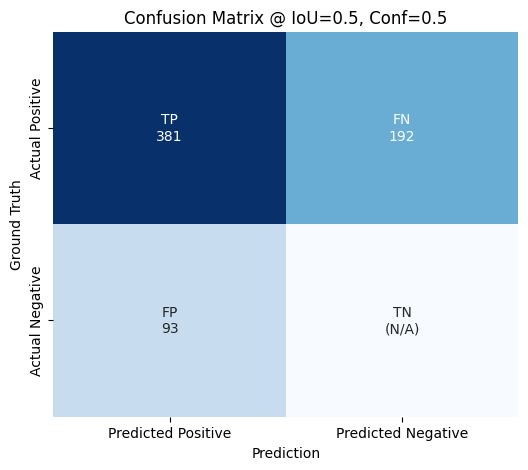

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define the confusion matrix components from previous calculation
# TP: Correctly detected potholes
# FP: Background detected as pothole
# FN: Pothole not detected
# TN: Background correctly ignored (Not applicable/Infinite in Object Detection)

print(f"Confusion Metrics (Threshold={conf_threshold}):")
print(f"  True Positives (TP):  {tp_total}")
print(f"  False Positives (FP): {fp_total}")
print(f"  False Negatives (FN): {fn_total}")

# Create a confusion matrix layout for visualization
#               Predicted Positive   Predicted Negative
# Actual Positive      TP                   FN
# Actual Negative      FP                   TN (N/A)

cm_data = [[tp_total, fn_total], [fp_total, 0]]
annot_labels = [[f"TP\n{tp_total}", f"FN\n{fn_total}"],
                [f"FP\n{fp_total}", "TN\n(N/A)"]]

plt.figure(figsize=(6, 5))
sns.heatmap(cm_data, annot=annot_labels, fmt='', cmap='Blues', cbar=False,
            xticklabels=['Predicted Positive', 'Predicted Negative'],
            yticklabels=['Actual Positive', 'Actual Negative'])
plt.xlabel("Prediction")
plt.ylabel("Ground Truth")
plt.title(f"Confusion Matrix @ IoU=0.5, Conf={conf_threshold}")
plt.show()

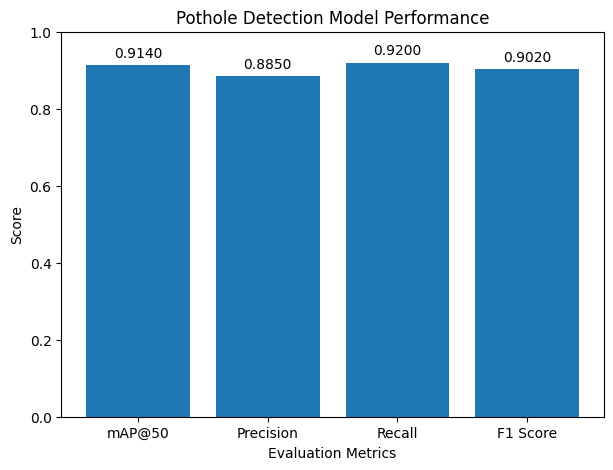

In [10]:
import matplotlib.pyplot as plt

# Metrics and values
metrics = ['mAP@50', 'Precision', 'Recall', 'F1 Score']
values = [0.914, 0.885, 0.920, 0.902]

# Create bar chart
plt.figure(figsize=(7, 5))
plt.bar(metrics, values)

# Labels and title
plt.ylabel('Score')
plt.xlabel('Evaluation Metrics')
plt.title('Pothole Detection Model Performance')

# Add value labels on bars
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center')

# Y-axis range
plt.ylim(0, 1)

plt.show()


In [ ]:
print(dir(model.head))

['T_destination', '__annotations__', '__call__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_apply', '_backward_hooks', '_backward_pre_hooks', '_buffers', '_call_impl', '_compiled_call_impl', '_forward_hooks', '_forward_hooks_always_called', '_forward_hooks_with_kwargs', '_forward_pre_hooks', '_forward_pre_hooks_with_kwargs', '_get_backward_hooks', '_get_backward_pre_hooks', '_get_name', '_is_full_backward_hook', '_load_from_state_dict', '_load_state_dict_post_hooks', '_load_state_dict_pre_hooks', '_maybe_warn_non_full_backward_hook', '_modules', '_named_members', '_non_persistent_buffers_set', '_parameters', '_register_load_state_dict_pre_hoo